# **Data Preparation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Makes plots a bit bigger and easier to read
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')


In [ ]:
df=pd.read_csv('USvideos.csv')

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 40949 rows, 16 columns


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [ ]:
# Quick look at column types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [ ]:
df.isnull().sum()


,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [ ]:
df['description'] = df['description'].fillna('')

# Confirm no more missing values anywhere
df.isnull().sum().sum()


np.int64(0)

In [ ]:
# Exact duplicate rows (every column identical) are almost always a data
# error, so we drop those.
duplicate_rows = df.duplicated().sum()
print(f"Fully duplicated rows: {duplicate_rows}")

df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")


Fully duplicated rows: 48
Shape after dropping duplicates: (40901, 16)


In [ ]:
# trending_date is stored like '17.14.11' (YY.DD.MM) and publish_time is a
# full ISO timestamp string. Both should be proper datetime objects, not text.

df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')

# category_id is really a category label, not a number to do math on
df['category_id'] = df['category_id'].astype('category')

# Ensure numeric columns are actually numeric and handle any 'None' strings
numeric_cols = ['views', 'likes', 'dislikes', 'comment_count']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop all rows containing any NaN value introduced by coercing or existing elsewhere.
# This ensures a completely clean DataFrame for the assertions.
initial_rows = df.shape[0]
df.dropna(inplace=True)
rows_dropped = initial_rows - df.shape[0]
print(f"Dropped {rows_dropped} rows containing NaN values after type conversions.\n")

df[['trending_date', 'publish_time', 'category_id']].dtypes

Dropped 0 rows containing NaN values after type conversions.



,0
trending_date,datetime64[ns]
publish_time,"datetime64[ns, UTC]"
category_id,category


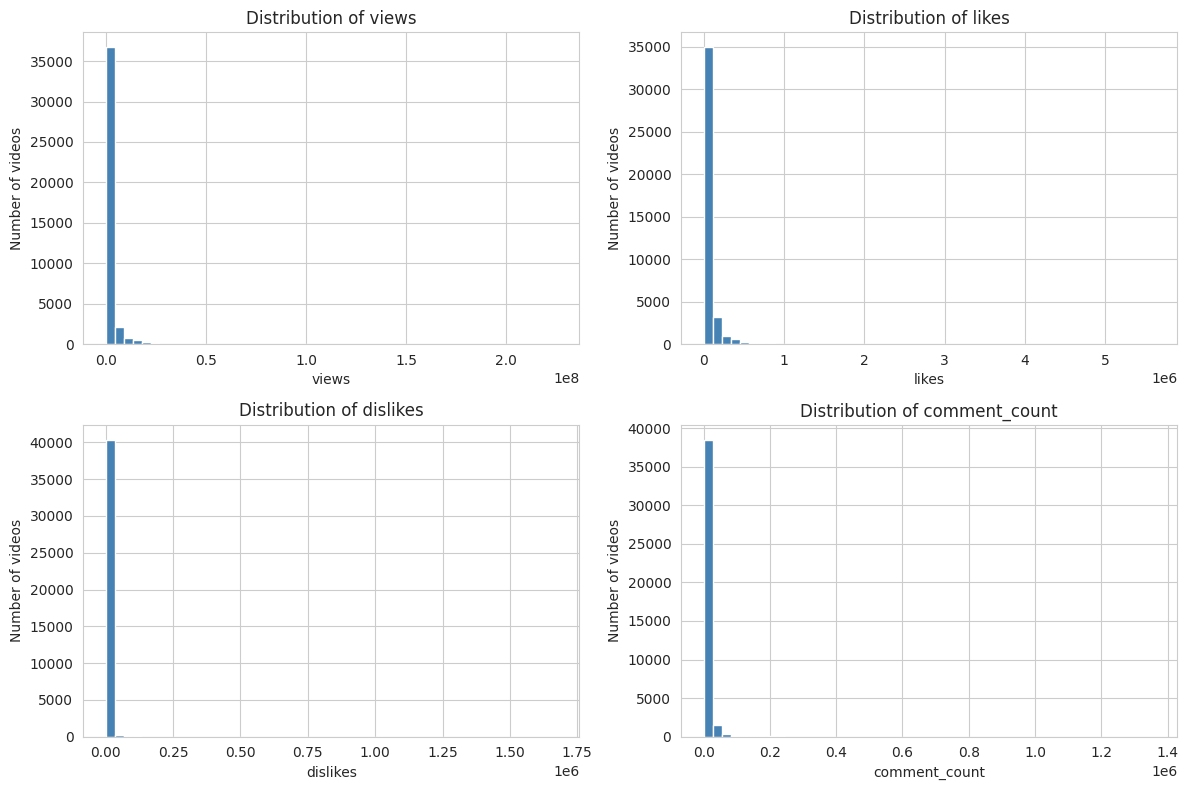

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols = ['views', 'likes', 'dislikes', 'comment_count']

for ax, col in zip(axes.flatten(), cols):
    ax.hist(df[col], bins=50, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of videos')

plt.tight_layout()
plt.show()



Notice these histograms are extremely skewed — most videos have relatively
few views/likes, and a handful of viral videos have millions. This is very
common for real-world engagement data, and it's useful to know before you
start modeling (a straight linear regression on raw counts will be pulled
hard by those outliers).


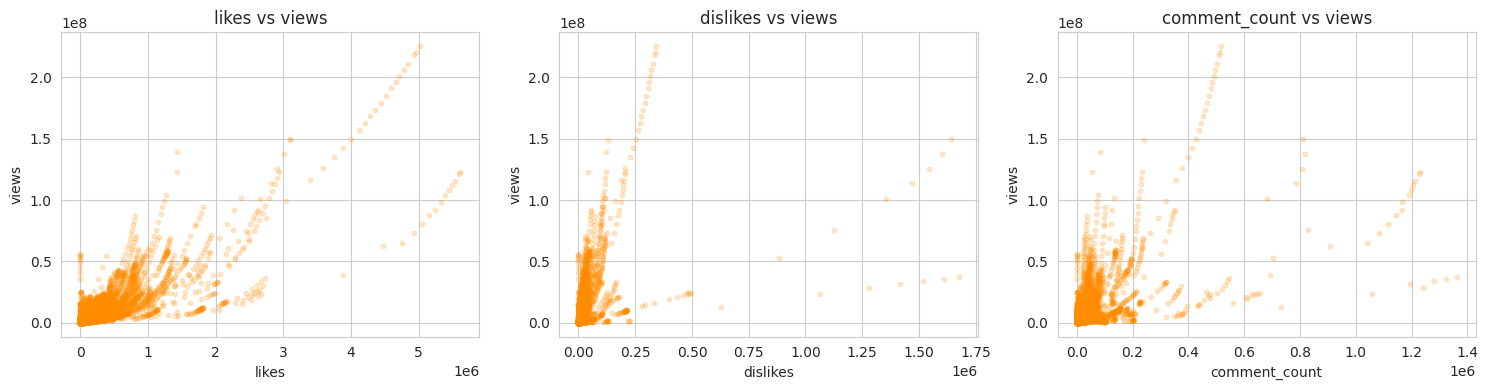

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features_to_check = ['likes', 'dislikes', 'comment_count']

for ax, col in zip(axes, features_to_check):
    ax.scatter(df[col], df['views'], alpha=0.2, s=10, color='darkorange')
    ax.set_xlabel(col)
    ax.set_ylabel('views')
    ax.set_title(f'{col} vs views')

plt.tight_layout()
plt.show()


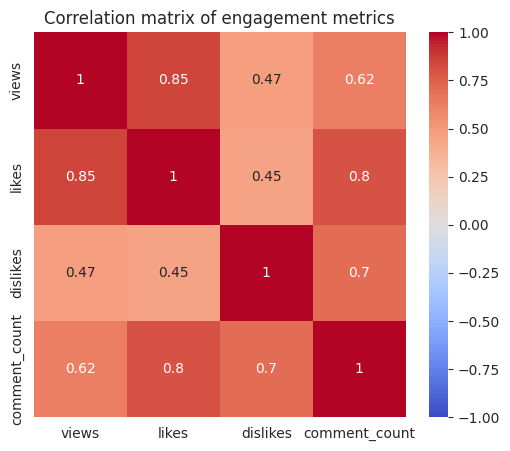

In [ ]:
numeric_cols = ['views', 'likes', 'dislikes', 'comment_count']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix of engagement metrics')
plt.show()


In [ ]:
feature_cols = ['likes', 'dislikes', 'comment_count']
target_col = 'views'

X = df[feature_cols]
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Turn the scaled array back into a labeled DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

print("Before scaling:")
print(X.describe().loc[['mean', 'std']])
print("\nAfter scaling (mean should be ~0, std should be ~1):")
print(X_scaled.describe().loc[['mean', 'std']])

Before scaling:
              likes      dislikes  comment_count
mean   74271.734285   3711.722134    8448.567150
std   228999.927881  29046.240549   37451.387082

After scaling (mean should be ~0, std should be ~1):
             likes      dislikes  comment_count
mean -2.223649e-17 -5.559123e-18   1.111825e-17
std   1.000012e+00  1.000012e+00   1.000012e+00


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (32720, 3)
X_test shape:  (8181, 3)
y_train shape: (32720,)
y_test shape:  (8181,)


In [ ]:
assert df.isnull().sum().sum() == 0, "There are still missing values!"
assert df.duplicated().sum() == 0, "There are still duplicate rows!"
assert X_train.shape[0] == y_train.shape[0], "X_train and y_train row counts don't match!"
assert abs(X_scaled['likes'].mean()) < 1e-6, "Scaling didn't center the data as expected!"

print("All checks passed. Data is clean, scaled, and split — ready for modeling.")

All checks passed. Data is clean, scaled, and split — ready for modeling.


# **Model**

In [ ]:
x_train=np.array(X_train)
y_train=np.array(y_train)

In [ ]:
print(type(x_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
print(x_train)
print(y_train)

[[-0.29067934 -0.09773233 -0.20916883]
 [-0.26702839 -0.12073043 -0.15483106]
 [-0.29913796 -0.12262398 -0.19055781]
 ...
 [-0.09339302 -0.08354788  0.32112509]
 [-0.16557734 -0.10850839 -0.15931693]
 [-0.31591546 -0.12348469 -0.22070393]]
[ 723501  295455  225280 ... 1196500  441164   64002]


###Cost Function
$$
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2
$$

In [ ]:
def cost_ftn(x,y,w,b):
  f_wb=np.dot(w,x)+b
  cost=0
  m=x_train.shape[0]
  for i in range (m):
    cost=cost+(f_wb[i]-y[i])**2
  return cost/(2*m)

###Derivatives
$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}\sum_{i=1}^{m}
\left(f_{w,b}(x^{(i)})-y^{(i)}\right)x^{(i)}
$$

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}\sum_{i=1}^{m}
\left(f_{w,b}(x^{(i)})-y^{(i)}\right)
$$

In [ ]:
def dj_dw (x,y,w,b):
  m=x.shape[0]
  f_wb=np.dot(x,w)+b
  dj_dw=0
  for i in range (m):
    dj_dw=dj_dw+((f_wb[i]-y[i])*x[i])
  return dj_dw/m

def dj_db (x,y,w,b):
  m=x.shape[0]
  f_wb=np.dot(x,w)+b
  dj_db=0
  for i in range (m):
    dj_db=dj_db+(f_wb[i]-y[i])
  return dj_db/m

###Gradient Descent
Repeat until convergence:

$$
w = w - \alpha \frac{\partial}{\partial w} J(w,b)
$$

$$
b = b - \alpha \frac{\partial}{\partial b} J(w,b)
$$

In [ ]:
def gradient_descent(x,y,alpha):
  m=x.shape[0]
  w=0
  b=0
  for i in range (1000):
    w=w-(alpha*dj_dw(x,y,w,b))
    b=b-(alpha*dj_db(x,y,w,b))
  return w,b

In [ ]:
gradient_descent(x_train,y_train,0.1)

(array([ 8211195.30478345,  2444107.99969082, -3680238.38728294]),
 np.float64(2368996.4998868722))

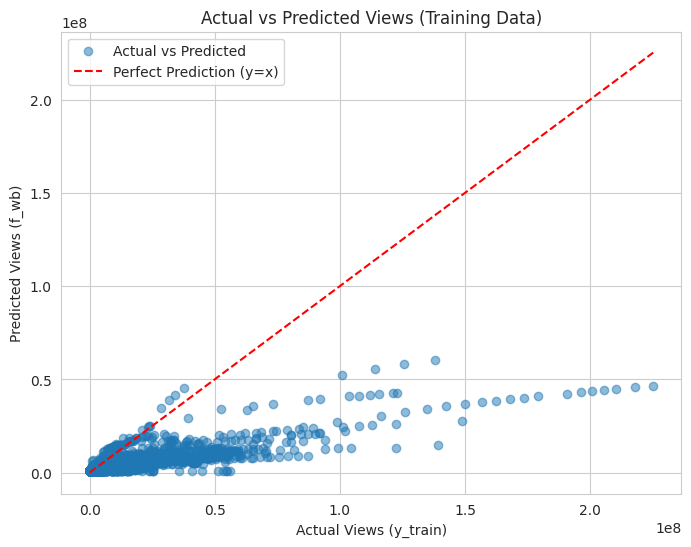

In [ ]:
w = np.array([1841434.93185662, 741824.62845073, -260701.65301107])
b = 1576104.57760572

# Calculate predictions using the provided w and b
f_wb = np.dot(x_train, w) + b

plt.figure(figsize=(8, 6))
# Scatter plot of actual vs predicted values
plt.scatter(y_train, f_wb, alpha=0.5, label='Actual vs Predicted')

# Plot the ideal 'perfect prediction' line (y = x)
min_val = min(y_train.min(), f_wb.min())
max_val = max(y_train.max(), f_wb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction (y=x)')

plt.title('Actual vs Predicted Views (Training Data)')
plt.xlabel('Actual Views (y_train)')
plt.ylabel('Predicted Views (f_wb)')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
(-0.503034*1841434.93185658 )+ (0.367005*741824.62845073)+	(-0.465432*-260701.65301103) +2368996.4998868722  # should be equal to 277928.0 as that's the first row of testing data

1836284.3599041193